# Установка зависимостей

In [40]:
!pip install catboost
!pip install numpy==1.23.5
!pip install pandas matplotlib scikit-learn gdown

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# Загрузка данных

In [41]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 17.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 10.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 17.4MB/s]


In [42]:
import pandas as pd

data = pd.read_csv('/content/train.csv')
X_test = pd.read_csv('/content/test.csv')
submission = pd.read_csv('/content/submission.csv')

print("Train data:")
display(data.head())
data.info()

Train data:


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

# Обработка пропусков и преобразование признаков

In [43]:
# Числовые признаки
num_cols = ['ClientPeriod', 'MonthlySpending', 'TotalSpent']

# Категориальные признаки
cat_cols = [
    'Sex', 'IsSeniorCitizen', 'HasPartner', 'HasChild', 'HasPhoneService',
    'HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService',
    'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess',
    'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone',
    'IsBillingPaperless', 'PaymentMethod'
]

# Преобразование числовых признаков
for col in num_cols:
    data[col] = pd.to_numeric(data[col].replace(' ', '0'))

# Преобразование категориальных признаков
data['Sex'].fillna('Unknown', inplace=True)

/tmp/ipykernel_2027/598754844.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sex'].fillna('Unknown', inplace=True)


# EDA (гистограммы числовых признаков)

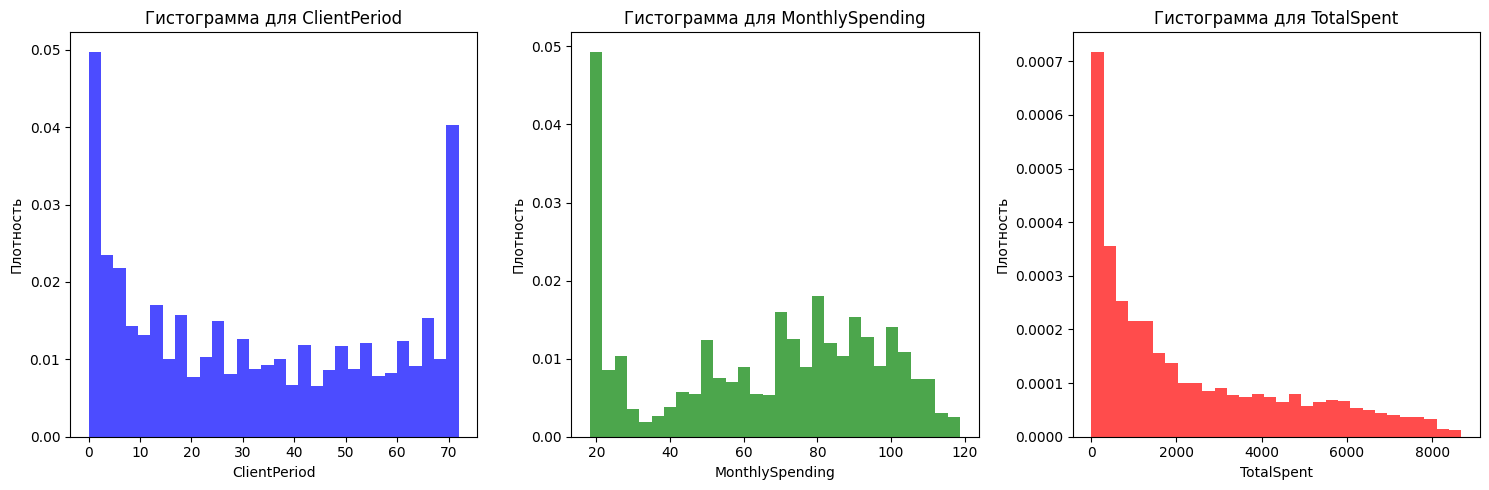

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['blue', 'green', 'red']

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=30, density=True, color=colors[i], alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Плотность')
    axes[i].set_title(f'Гистограмма для {col}')

plt.tight_layout()
plt.show()

# EDA (круговые диаграммы категориальных признаков)

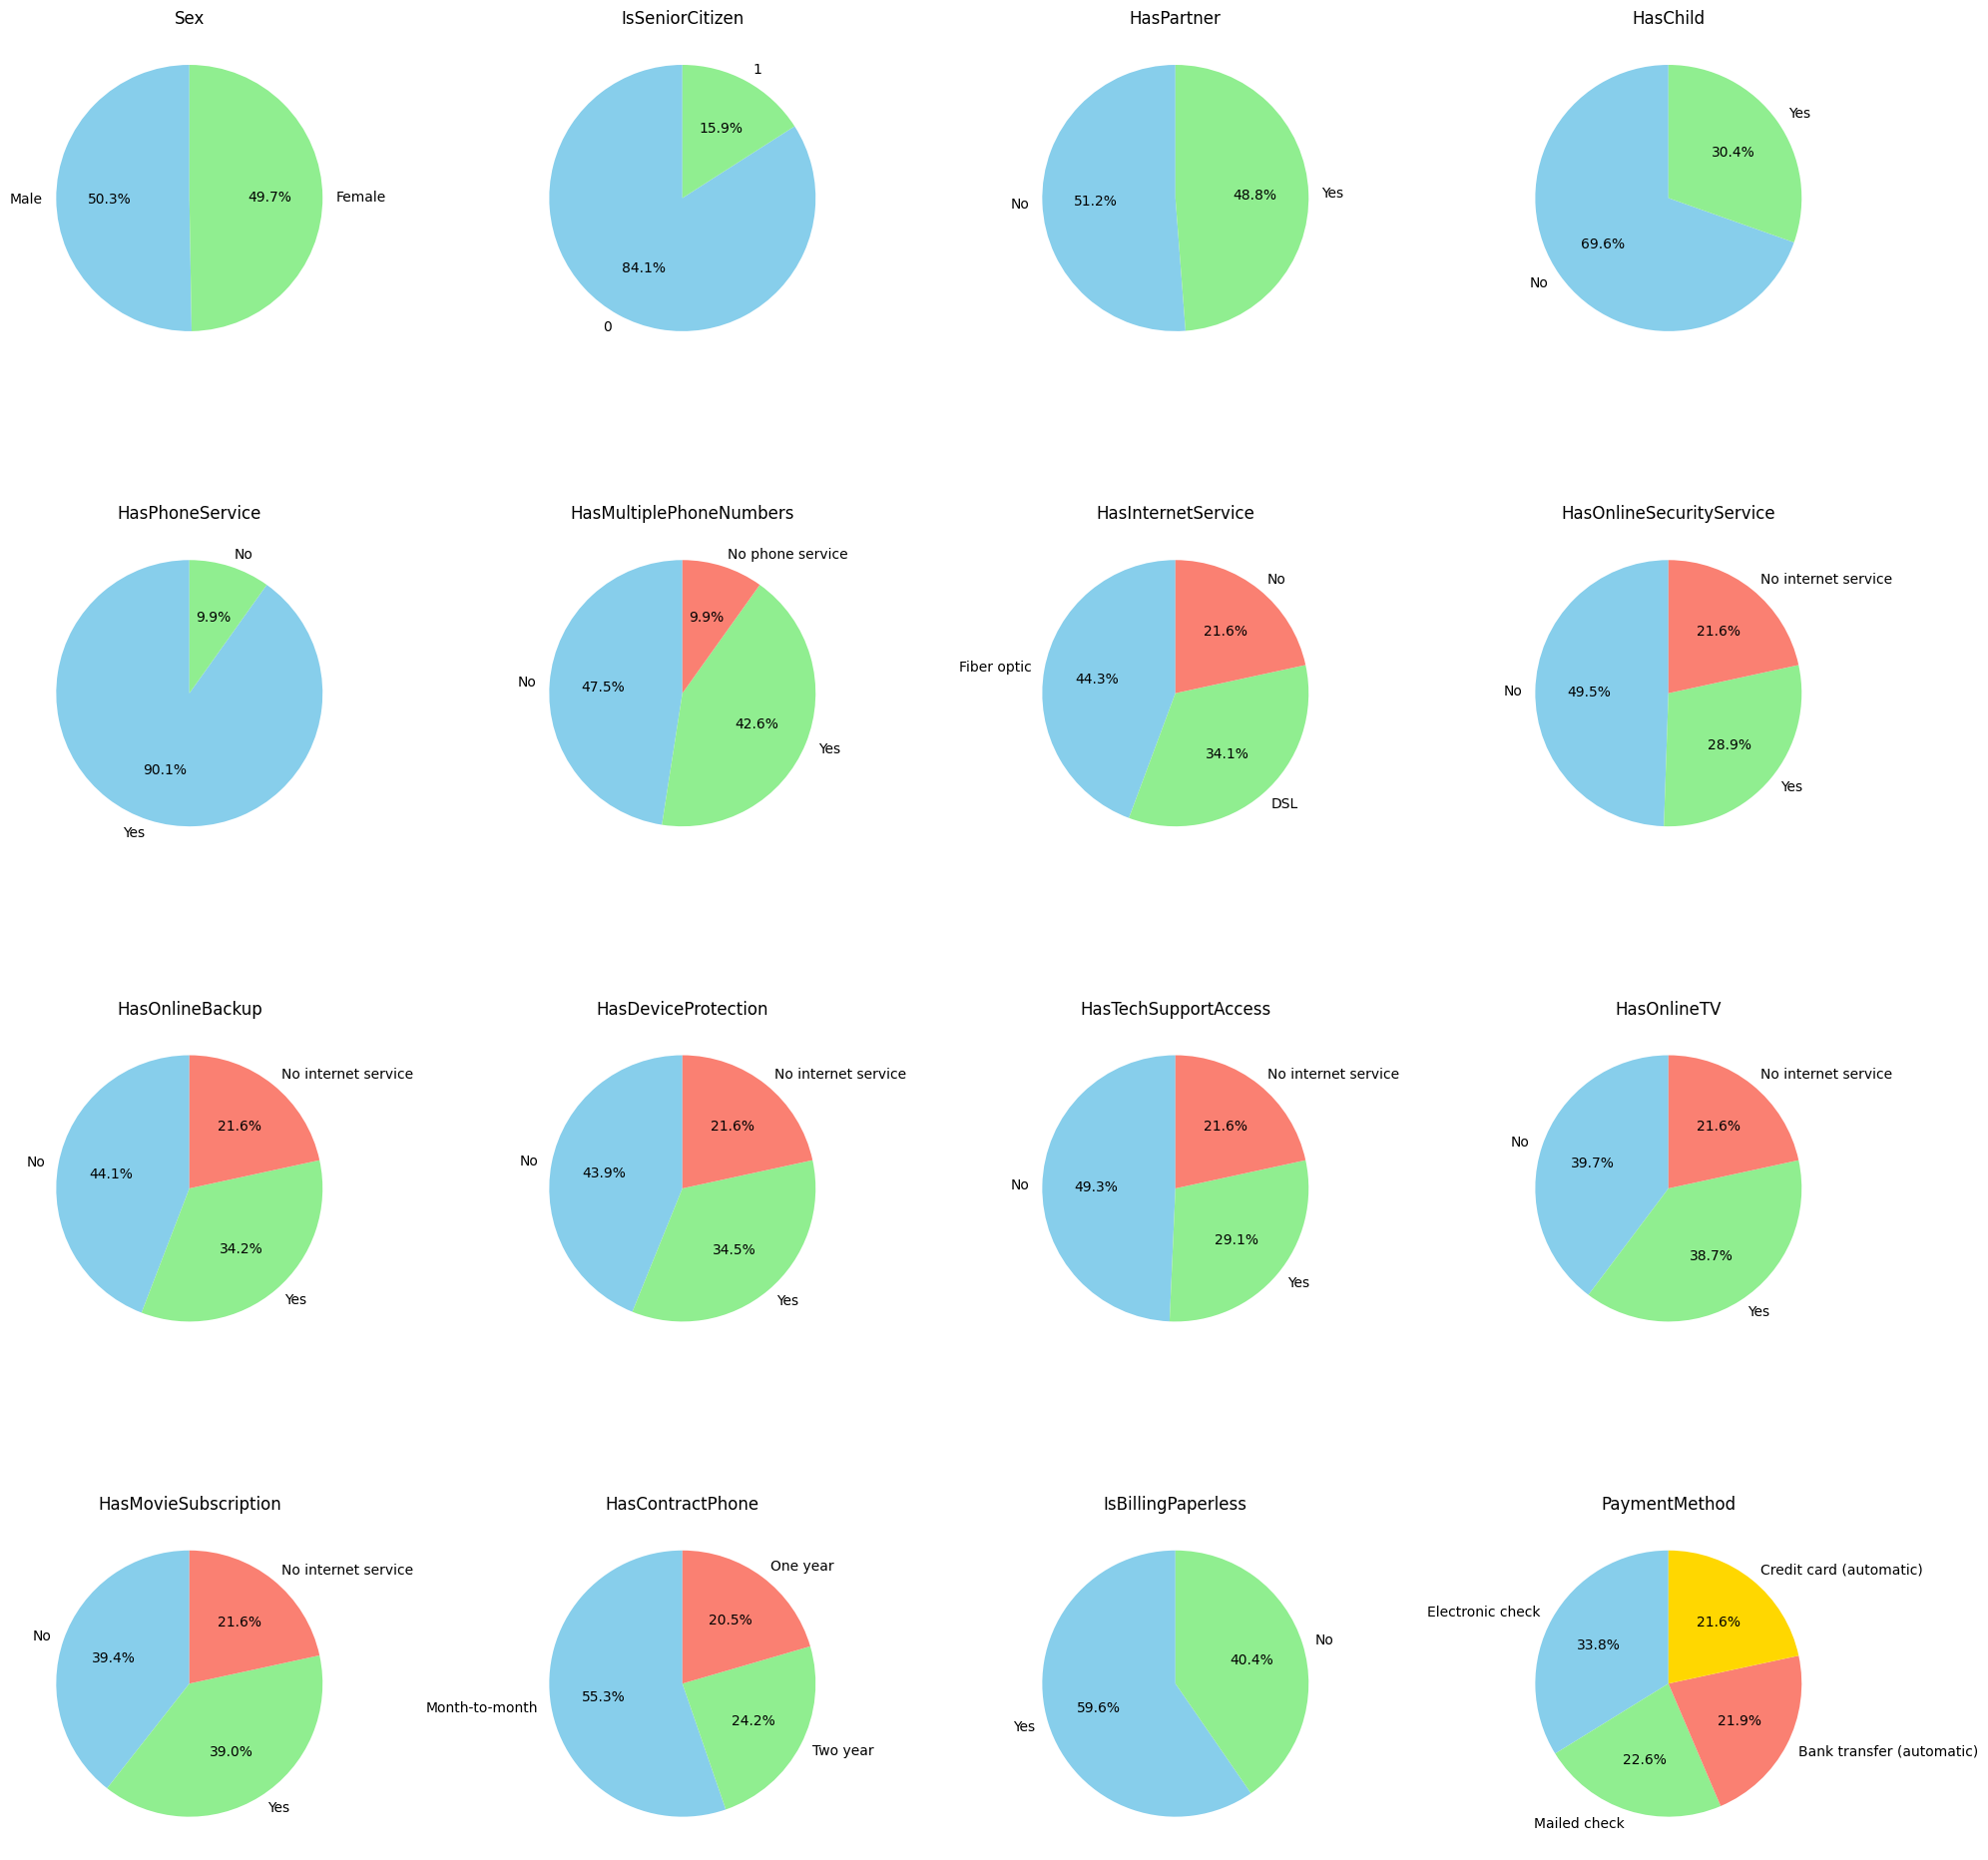

In [45]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    value_counts = data[col].value_counts()
    axes[i].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90,
                colors=['skyblue', 'lightgreen', 'salmon', 'gold'])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Распределение целевой переменной

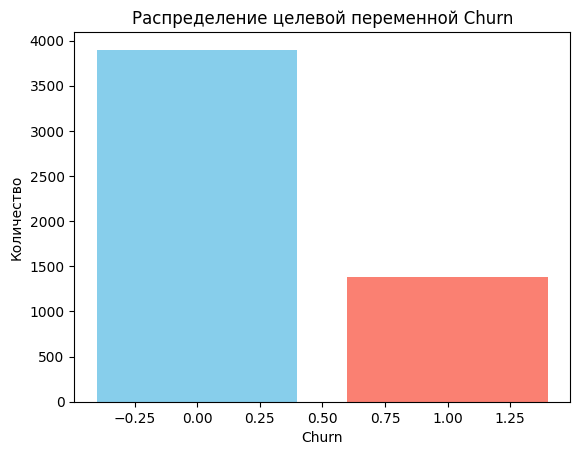

In [46]:
target_col = 'Churn'
target_counts = data[target_col].value_counts()

plt.bar(target_counts.index, target_counts.values, color=['skyblue', 'salmon'])
plt.xlabel('Churn')
plt.ylabel('Количество')
plt.title('Распределение целевой переменной Churn')
plt.show()

# Подготовка данных для моделей

In [47]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Трансформеры
numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

X = data.drop('Churn', axis=1)
y = data['Churn']

# Logistic Regression + GridSearchCV

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {'classifier__C': [100, 10, 1, 0.1, 0.01, 0.001]}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', refit=True)
grid_search.fit(X, y)

best_c = grid_search.best_params_['classifier__C']
best_score = grid_search.best_score_

print(f"Лучший C: {best_c}, ROC-AUC: {best_score:.4f}")

Лучший C: 10, ROC-AUC: 0.8451


# CatBoostClassifier

In [49]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

cat_model = CatBoostClassifier(verbose=0, random_seed=42)
cat_model.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_valid, y_valid), early_stopping_rounds=50)

y_pred_proba = cat_model.predict_proba(X_valid)[:, 1]
roc_auc_default = roc_auc_score(y_valid, y_pred_proba)
print(f"ROC-AUC CatBoost (default params): {roc_auc_default:.4f}")

ROC-AUC CatBoost (default params): 0.8462


# Подбор параметров CatBoost

In [50]:
params_to_test = {'iterations': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.3]}
best_roc_auc = 0
best_params = {}

for iterations in params_to_test['iterations']:
    for lr in params_to_test['learning_rate']:
        model = CatBoostClassifier(iterations=iterations, learning_rate=lr, verbose=0, random_seed=42)
        model.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_valid, y_valid), early_stopping_rounds=50)
        y_pred = model.predict_proba(X_valid)[:, 1]
        roc_auc = roc_auc_score(y_valid, y_pred)
        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_params = {'iterations': iterations, 'learning_rate': lr}

print(f"Лучший ROC-AUC: {best_roc_auc:.4f}, Параметры: {best_params}")

Лучший ROC-AUC: 0.8464, Параметры: {'iterations': 100, 'learning_rate': 0.3}


# Предсказание на тестовых данных

In [51]:
# В Colab файлы находятся в /content/
X_test = pd.read_csv('/content/test.csv')
submission = pd.read_csv('/content/submission.csv')

# Выбираем модель: Logistic Regression или CatBoost
# best_model = grid_search    # Logistic Regression
best_model = cat_model        # CatBoost

# Для Logistic Regression нужно преобразовать тестовые данные через preprocessor
if best_model == grid_search:
    X_test_processed = preprocessor.transform(X_test)
else:
    X_test_processed = X_test

submission['Churn'] = best_model.predict_proba(X_test_processed)[:, 1]

submission.to_csv('/content/submission.csv', index=False)
print("Файл submission.csv создан!")

Файл submission.csv создан!
